# Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from ucimlrepo import fetch_ucirepo 

# Data Fetching & Preprocessing

In [2]:
print("Fetching dataset...")
metro_interstate_traffic_volume = fetch_ucirepo(id=492) 
X = metro_interstate_traffic_volume.data.features 
y = metro_interstate_traffic_volume.data.targets 

df = X.copy()
df['traffic_volume'] = y

print("Processing features...")
# Convert to datetime and extract useful time features
df['date_time'] = pd.to_datetime(df['date_time'])
df['hour'] = df['date_time'].dt.hour
df['day_of_week'] = df['date_time'].dt.dayofweek
df['month'] = df['date_time'].dt.month
# 1 if weekend, 0 if weekday
df['is_weekend'] = df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

# Select the final features for the model
features_to_use = ['temp', 'rain_1h', 'clouds_all', 'hour', 'day_of_week', 'month', 'is_weekend']
X_processed = df[features_to_use]
y_processed = df['traffic_volume']

print("Data processing complete!")

Fetching dataset...
Processing features...
Data processing complete!


# Model Training

In [3]:
print("Splitting data into Train (70%), Validate (15%), and Test (15%) sets...")

# First split: 70% Train, 30% Temp
X_train, X_temp, y_train, y_temp = train_test_split(X_processed, y_processed, test_size=0.30, random_state=42)

# Second split: Cut the Temp set in half to get 15% Val and 15% Test
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

print(f"Training rows: {len(X_train)} | Validation rows: {len(X_val)} | Testing rows: {len(X_test)}")

print("Training Random Forest Regressor (this may take a moment)...")
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Generate Predictions
val_predictions = rf_model.predict(X_val)
test_predictions = rf_model.predict(X_test)

Splitting data into Train (70%), Validate (15%), and Test (15%) sets...
Training rows: 33742 | Validation rows: 7231 | Testing rows: 7231
Training Random Forest Regressor (this may take a moment)...


# Evaluation Metrics

In [6]:
def print_metrics(dataset_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n--- {dataset_name} Results ---")
    print(f"R-squared (R²): {r2:.4f}")
    print(f"Mean Absolute Error (MAE): {mae:.0f} cars")
    print(f"Root Mean Squared Error (RMSE): {rmse:.0f} cars")

print_metrics("Validation Set", y_val, val_predictions)
print_metrics("Test Set", y_test, test_predictions)


--- Validation Set Results ---
R-squared (R²): 0.9470
Mean Absolute Error (MAE): 244 cars
Root Mean Squared Error (RMSE): 459 cars

--- Test Set Results ---
R-squared (R²): 0.9568
Mean Absolute Error (MAE): 234 cars
Root Mean Squared Error (RMSE): 415 cars


# Generating the Plots

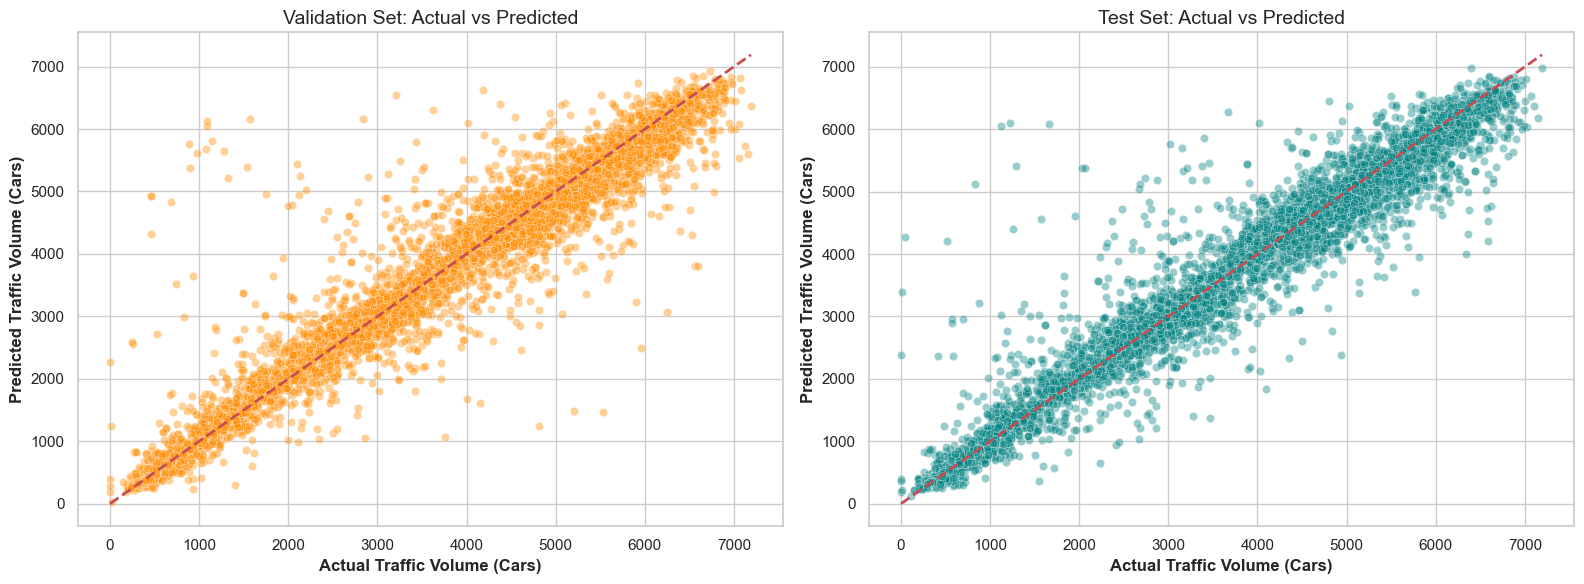

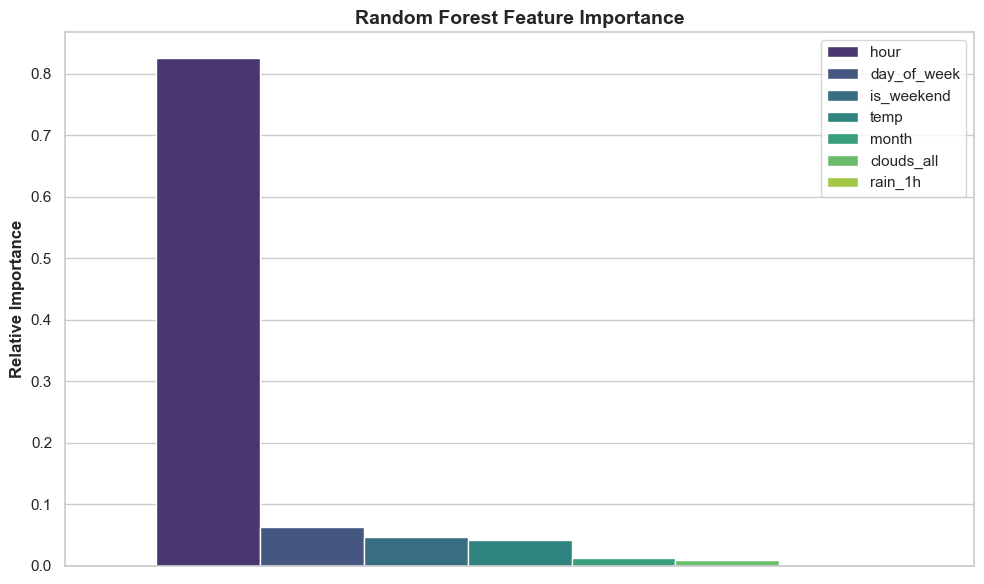

In [7]:
sns.set_theme(style="whitegrid")

# 1. Validation and Test Scatter Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Validation Plot using Seaborn
sns.scatterplot(x=y_val, y=val_predictions, alpha=0.4, color='darkorange', ax=ax1)
ax1.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
ax1.set_xlabel('Actual Traffic Volume (Cars)', fontweight='bold')
ax1.set_ylabel('Predicted Traffic Volume (Cars)', fontweight='bold')
ax1.set_title('Validation Set: Actual vs Predicted', fontsize=14)

# Test Plot using Seaborn
sns.scatterplot(x=y_test, y=test_predictions, alpha=0.4, color='teal', ax=ax2)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax2.set_xlabel('Actual Traffic Volume (Cars)', fontweight='bold')
ax2.set_ylabel('Predicted Traffic Volume (Cars)', fontweight='bold')
ax2.set_title('Test Set: Actual vs Predicted', fontsize=14)

plt.tight_layout()
plt.show()

# 2. Feature Importance Bar Chart
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1]
sorted_features = [features_to_use[i] for i in indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 6))

# Seaborn barplot with a modern color palette
sns.barplot(hue=sorted_features, y=sorted_importances, palette="viridis")

plt.xticks(rotation=45, ha='right', fontsize=11)
plt.ylabel('Relative Importance', fontweight='bold')
plt.title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()